In [ ]:
!pip install qiskit qiskit-aer
!pip install qiskit_ibm_runtime
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 151.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 10.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.4/149.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 353.2/353.2 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.9/434.9 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5

In [ ]:
import hashlib
import random
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import math
import time

In [ ]:
# SETUP: input your API token below and choose a machine you have access to
QiskitRuntimeService.save_account(
	channel = "ibm_quantum",
	token = "API TOKEN HERE"
)
machine = "ibm_rensselaer"

In [ ]:
def next_power_of_two(n):
    return 1 << (n - 1).bit_length()

def pad_password_list(password_list):
    padded_size = next_power_of_two(len(password_list))
    return password_list + [""] * (padded_size - len(password_list))  # pad with empty strings

In [ ]:
password_list = [
  "123456",
  "12345",
  "123456789",
  "password",
  "iloveyou",
  "princess",
  "1234567",
  "12345678",
  "abc123",
  "nicole",
  "daniel",
  "babygirl",
  "monkey",
  "lovely",
  "jessica",
  "654321",
  "michael",
  "ashley",
  "qwerty",
  "111111",
  "iloveu",
  "000000",
  "michelle",
  "tigger",
  "sunshine",
  "chocolate",
  "password1",
  "soccer",
  "anthony",
  "friends",
  "butterfly",
  "purple",
  "angel",
  "jordan",
  "liverpool",
  "justin",
  "loveme",
  "fuckyou",
  "123123",
  "football",
  "secret",
  "andrea",
  "carlos",
  "jennifer",
  "biteme",
  "maggie",
  "basketball",
  "biteme1",
  "matthew",
  "access",
]
len(password_list)


50

In [ ]:
hashed_targets = [
    hashlib.sha1("qwerty".encode()).hexdigest(),
    hashlib.sha1("basketball".encode()).hexdigest(),
    hashlib.sha1("password".encode()).hexdigest()
]

In [ ]:
password_list = pad_password_list(password_list)
bit_length = int(math.log2(len(password_list)))
n_physical = 3 * bit_length

In [ ]:
bitstring_map = {format(i, f'0{bit_length}b'): pw for i, pw in enumerate(password_list)}
inverse_map = {v: k for k, v in bitstring_map.items() if v}  # ignore padding

def find_matching_bitstring(target_hash):
    for bitstring, pw in bitstring_map.items():
        if pw == "":
            continue
        if hashlib.sha1(pw.encode()).hexdigest() == target_hash:
            return bitstring
    return None


In [ ]:
def build_oracle(target, n, output=False):
    qc = QuantumCircuit(n + 1)  # +1 ancilla

    # Step 1: Mark the target bitstring using X gates
    for i, bit in enumerate(target):
        if bit == '0':
            qc.x(i)

    # Step 2: Prepare ancilla in |-⟩ state
    qc.x(n)
    qc.h(n)

    # Step 3: Flip ancilla if all other qubits match (oracle condition)
    qc.mcx(list(range(n)), n)

    # Step 4: Uncompute ancilla state
    qc.h(n)
    qc.x(n)

    # Step 5: Undo the Xs from step 1
    for i, bit in enumerate(target):
        if bit == '0':
            qc.x(i)

    if output:
        # fig = qc.draw(output='mpl')  # High-quality Matplotlib image
        # fig.savefig("oracle.png", dpi=300, bbox_inches='tight')
        print("$"*30)
        print("Oracle")
        print(qc.draw('latex_source'))
        print(qc.draw())

    return qc

In [ ]:
def diffuser(n, output=False):
    qc = QuantumCircuit(n)
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    qc.x(range(n))
    qc.h(range(n))

    if output:
        # fig = qc.draw(output='mpl')  # High-quality Matplotlib image
        # fig.savefig("diffuser.png", dpi=300, bbox_inches='tight')
        print("$"*30)
        print("Diffuser")
        print(qc.draw('latex_source'))
        print(qc.draw())


    return qc

In [ ]:
# encode and decode functions for QEC
def encode_bit_flip(qc, q):
    qc.cx(q, q + 1)
    qc.cx(q, q + 2)

def decode_bit_flip(qc, q):
    qc.cx(q, q + 1)
    qc.cx(q, q + 2)
    qc.ccx(q + 1, q + 2, q)

In [ ]:
def build_and_run_circuit(target_bitstring, iterations, shots, output=False, noisy=False):
    print(f"Expected bitstring for target: {target_bitstring}")

    # Build Grover circuit
    qc = QuantumCircuit(bit_length + 1, bit_length)
    qc.h(range(bit_length))

    oracle_gate = build_oracle(target_bitstring, bit_length, output).to_gate(label="Oracle")
    diffuser_gate = diffuser(bit_length, output).to_gate(label="Diffuser")

    for _ in range(iterations):
        qc.append(oracle_gate, range(bit_length + 1))
        qc.append(diffuser_gate, range(bit_length))
    qc.measure(range(bit_length), range(bit_length))

    # Starting timer
    start_time = time.time()

    # Transpile before running
    if not noisy:
        compiled = transpile(qc, sim)

    # Transpile noisy simulation
    else:
        passmanager = generate_preset_pass_manager(optimization_level = 3, backend = sim)
        compiled = passmanager.run(qc)

    # 1024 shots/iterations
    result = sim.run(compiled, shots=shots).result()
    end_time = time.time()
    counts = result.get_counts()

    most_common = max(counts, key=counts.get)
    corrected_bitstring = most_common[::-1]
    found_password = bitstring_map.get(corrected_bitstring, "Unknown")
    found_hash = hashlib.sha256(found_password.encode()).hexdigest()

    if found_password != "Unknown":

        # Output result
        confidence = counts.get(most_common, 0) / shots
        print(f"Cracked Hash: {target_hash}")
        print(f"Found bitstring: {corrected_bitstring}")
        print(f"Found password: {found_password}")
        print(f"Confidence on correct bitstring: {confidence:.2%}")
        print(f"Match: {found_hash == target_hash}")
        print(f"Time taken: {end_time - start_time} seconds")
        if output:
            # fig = qc.draw(output='mpl')  # High-quality Matplotlib image
            # fig.savefig("whole_grover_circuit.png", dpi=300, bbox_inches='tight')
            print("$"*30)
            print("Circtuit")
            print(qc.draw('latex_source'))

In [ ]:
""" Base Quantum no noise or error correction """

print(f"Passwords in input list {len(password_list)}")

N = len(password_list)
k_iterations = math.floor((math.pi / 4) * math.sqrt(N))
print(f"Number of iterations: {k_iterations}")

sim = AerSimulator()

for i, target_hash in enumerate(hashed_targets):
    target_bitstring = find_matching_bitstring(target_hash)

    if not target_bitstring:
        print(f"Target hash {target_hash[:10]}... not found in password list.")
        continue

    print("#"*50)
    print(f"1 Shot with 1 oracle calls")
    build_and_run_circuit(target_bitstring, 1, 1, i==0)
    print("#"*50)
    print(f"1 Shot with {k_iterations} oracle calls")
    build_and_run_circuit(target_bitstring, k_iterations, 1)
    print("#"*50)
    print(f"100 Shots with 1 oracle call")
    build_and_run_circuit(target_bitstring, 1, 100)
    print("#"*50)
    print(f"100 Shots with {k_iterations} oracle calls")
    build_and_run_circuit(target_bitstring, k_iterations, 100, False)
    print()

Passwords in input list 64
Number of iterations: 6
##################################################
1 Shot with 1 oracle calls
Expected bitstring for target: 010010
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
Oracle
\documentclass[border=2px]{standalone}

\usepackage[braket, qm]{qcircuit}
\usepackage{graphicx}

\begin{document}
\scalebox{1.0}{
\Qcircuit @C=1.0em @R=0.2em @!R { \\
	 	\nghost{{q}_{0} :  } & \lstick{{q}_{0} :  } & \gate{\mathrm{X}} & \qw & \ctrl{1} & \gate{\mathrm{X}} & \qw & \qw & \qw\\
	 	\nghost{{q}_{1} :  } & \lstick{{q}_{1} :  } & \qw & \qw & \ctrl{1} & \qw & \qw & \qw & \qw\\
	 	\nghost{{q}_{2} :  } & \lstick{{q}_{2} :  } & \gate{\mathrm{X}} & \qw & \ctrl{1} & \gate{\mathrm{X}} & \qw & \qw & \qw\\
	 	\nghost{{q}_{3} :  } & \lstick{{q}_{3} :  } & \gate{\mathrm{X}} & \qw & \ctrl{1} & \gate{\mathrm{X}} & \qw & \qw & \qw\\
	 	\nghost{{q}_{4} :  } & \lstick{{q}_{4} :  } & \qw & \qw & \ctrl{1} & \qw & \qw & \qw & \qw\\
	 	\nghost{{q}_{5} :  } & \lstick{{q}_{5} :  } & \gate{\mathrm{X

In [ ]:
""" With noise model and error correction """

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer.noise import NoiseModel
from qiskit.transpiler import generate_preset_pass_manager

# getting noise model from ibm_rensselaer backend
service = QiskitRuntimeService()
backend = service.backend(machine)
noise_model = NoiseModel.from_backend(backend)

sim = AerSimulator(noise_model = noise_model)

for i, target_hash in enumerate(hashed_targets):
    target_bitstring = find_matching_bitstring(target_hash)

    if not target_bitstring:
        print(f"Target hash {target_hash[:10]}... not found in password list.")
        continue

    print("#"*50)
    print(f"1 Shot with 1 oracle calls")
    build_and_run_circuit(target_bitstring, 1, 1, noisy=True)
    print("#"*50)
    print(f"1 Shot with {k_iterations} oracle calls")
    build_and_run_circuit(target_bitstring, k_iterations, 1, noisy=True)
    print("#"*50)
    print(f"100 Shots with 1 oracle call")
    build_and_run_circuit(target_bitstring, 1, 100, noisy=True)
    print("#"*50)
    print(f"100 Shots with {k_iterations} oracle calls")
    build_and_run_circuit(target_bitstring, k_iterations, 100, i==0, noisy=True)
    print()

AccountNotFoundError: 'Unable to find account.'

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def run_with_zne(target_bitstring, iterations, shots):
    """
    Run the Grover circuit for the given target with Zero-Noise Extrapolation (ZNE).

    This function constructs the Grover circuit for a target bitstring and simulates its execution
    under depolarizing noise scaled by different factors (1.0, 2.0, 3.0). For each noise level,
    it measures the confidence (frequency) of the most common output bitstring. A linear fit is
    applied to these confidence values to extrapolate the expected success rate at zero noise.
    Finally, it plots the noise scaling vs. confidence and prints the extrapolated confidence
    along with the predicted bitstring.
    """
    qc = QuantumCircuit(bit_length + 1, bit_length)
    qc.h(range(bit_length))
    oracle_gate = build_oracle(target_bitstring, bit_length).to_gate(label="Oracle")
    diffuser_gate = diffuser(bit_length).to_gate(label="Diffuser")
    for _ in range(iterations):
        qc.append(oracle_gate, range(bit_length + 1))
        qc.append(diffuser_gate, range(bit_length))
    qc.measure(range(bit_length), range(bit_length))
    compiled = transpile(qc, sim)

    base_error_1q = 0.01
    base_error_2q = 0.03

    noise_factors = [1.0, 2.0, 3.0]
    confidences = []

    for scale in noise_factors:
        noise_model = NoiseModel()
        error1 = depolarizing_error(base_error_1q * scale, 1)
        error2 = depolarizing_error(base_error_2q * scale, 2)
        noise_model.add_all_qubit_quantum_error(error1, ['u1', 'u2', 'u3'])
        noise_model.add_all_qubit_quantum_error(error2, ['cx'])

        result = sim.run(compiled, shots=shots, noise_model=noise_model).result()
        counts = result.get_counts()
        most_common = max(counts, key=counts.get)
        confidence = counts[most_common] / shots
        confidences.append(confidence)

    coeffs = np.polyfit(noise_factors, confidences, 1)
    extrap_confidence = np.polyval(coeffs, 0.0)

    plt.figure(figsize=(6,4))
    plt.scatter(noise_factors, [c*100 for c in confidences], color='blue', label='Measured confidence')
    fit_x = np.linspace(0, max(noise_factors), 100)
    fit_y = np.polyval(coeffs, fit_x)
    plt.plot(fit_x, fit_y*100, color='orange', linestyle='--', label='Linear fit')
    plt.scatter([0], [extrap_confidence*100], color='red', label='Extrapolated (0 noise)')
    found_pw = bitstring_map.get(target_bitstring, "Unknown")
    plt.title(f"Noise Scaling vs Confidence (target='{found_pw}', bits={target_bitstring})")
    plt.xlabel("Noise scale factor")
    plt.ylabel("Success confidence (%)")
    plt.ylim(0, 105)
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Extrapolated confidence: {extrap_confidence:.2%}")
    print(f"Predicted correct bitstring: {target_bitstring}")


--- Zero-Noise Extrapolation for target hash: b1b3773a05... ---


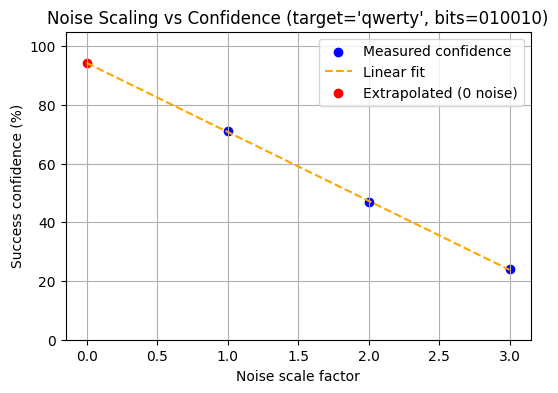

Extrapolated confidence: 94.33%
Predicted correct bitstring: 010010

--- Zero-Noise Extrapolation for target hash: 468ee5cbd5... ---


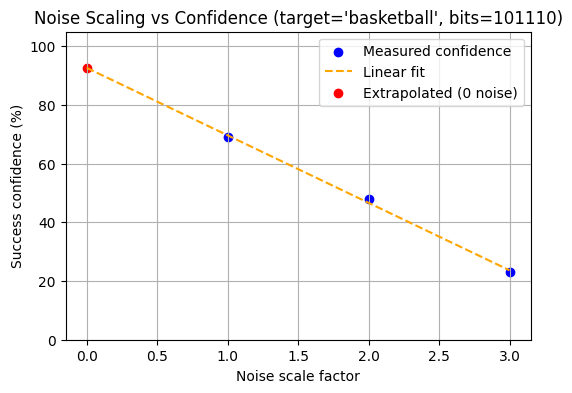

Extrapolated confidence: 92.67%
Predicted correct bitstring: 101110

--- Zero-Noise Extrapolation for target hash: 5baa61e4c9... ---


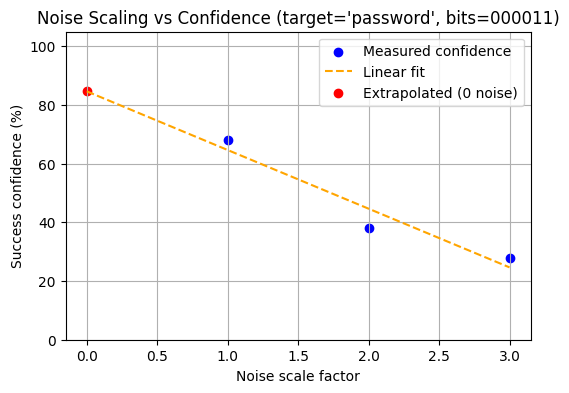

Extrapolated confidence: 84.67%
Predicted correct bitstring: 000011


In [ ]:
# Apply Zero-Noise Extrapolation for each target (after normal Grover runs)
for target_hash in hashed_targets:
    target_bitstring = find_matching_bitstring(target_hash)
    if not target_bitstring:
        # Skip if the target hash was not in our password list
        continue
    print("\n--- Zero-Noise Extrapolation for target hash:", target_hash[:10]+"... ---")
    run_with_zne(target_bitstring, k_iterations, 100)